In [53]:
import joblib
from scipy.stats import pearsonr
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    log_loss,
    classification_report,
    explained_variance_score
)
import numpy as np
import pandas as pd
import shap
results = []

# 定义函数用于计算指标
def evaluate_model(model_name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) if np.all(y_test != 0) else np.nan
    ev = explained_variance_score(y_test, y_pred)
    R2,p=pearsonr(y_test, y_pred)
    results.append({
        "R²": r2,
        "MSE/10^-4": mse*10000,
        "MAE/10^-2": mae*100,
        "R-Pearso": R2,
        "Model": model_name
    })

In [54]:


gbr_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_gbr_model_LC.pkl')
xgb_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_xgb_model_LC.pkl')
lgbm_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_lgb_model_LC.pkl')
cat_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_catboost_model_LC.pkl')
rf_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_rf_model_LC.pkl')
ada_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_adaboost_model_LC.pkl')
lasso_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_lasso_model_LC.pkl')
ridge_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_ridge_model_LC.pkl')
elastic_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_elasticnet_model_LC.pkl')
stacking_regressor_lc = joblib.load('/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/final_stacking_model_LC.pkl')
scalar_lc = joblib.load("/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/scaler_LC.pkl")
base_learners = [
    ("XGBoost", xgb_regressor_lc),
    ("AdaBoost",ada_regressor_lc),
     ("CatBoost", cat_regressor_lc),
    ("LightGBM", lgbm_regressor_lc),
    ("GBDT", gbr_regressor_lc),
    ("RandomForest", rf_regressor_lc),
    ("Lasso", lasso_regressor_lc),
    ("Ridge", ridge_regressor_lc),
    ("ElasticNet", elastic_regressor_lc)
    
]
test_lc = pd.read_csv("/Users/jiaoyuan/Documents/GitHub/code_ml_dft/SGM_LC-wPBE/Stacking_model/test_data_LC.csv")
x_test_lc = test_lc.drop(columns=['best_omega'], errors='ignore')
y_test_lc = test_lc['best_omega']
x_test_lc = scalar_lc.transform(x_test_lc)
y_pred_lc = stacking_regressor_lc .predict(x_test_lc)
evaluate_model("Stacking Regressor", y_test_lc, y_pred_lc)

# 评估基学习器
for name, model in base_learners:
    y_pred = model.predict(x_test_lc)
    evaluate_model(name, y_test_lc, y_pred)

# 输出结果
results_df = pd.DataFrame(results)

# 打印表格
print(results_df)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.5.1 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.3.0. This might lead to breaking code or inv

         R²  MSE/10^-4  MAE/10^-2  R-Pearso               Model
0  0.876450   0.868556   0.632513  0.936610  Stacking Regressor
1  0.862876   0.963982   0.675394  0.930676             XGBoost
2  0.862174   0.968913   0.691475  0.931315            AdaBoost
3  0.858273   0.996341   0.685392  0.927702            CatBoost
4  0.870741   0.908689   0.659139  0.934169            LightGBM
5  0.866096   0.941344   0.666875  0.932505                GBDT
6  0.861395   0.974389   0.700237  0.930896        RandomForest
7  0.827068   1.215707   0.771515  0.909698               Lasso
8  0.824564   1.233310   0.774719  0.908503               Ridge
9  0.827286   1.214173   0.771637  0.909817          ElasticNet


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:464: UserWarning: X does not have v

In [55]:
test_lc

,x,y,z,tot,xx,yy,zz,xy,xz,yz,...,UMAP2,UMAP3,UMAP4,UMAP5,UMAP6,UMAP7,UMAP8,UMAP9,UMAP10,best_omega
0,0.4000,1.7686,0.0002,1.8132,-149.1845,-129.3839,-170.8446,-9.5014,0.0266,-0.0161,...,1.440743,8.915274,9.354097,2.358021,6.953269,1.299300,1.425522,7.579300,5.179375,0.186037
1,-0.2046,5.5192,0.5265,5.5480,-81.5805,-117.5149,-113.4104,-21.4126,-4.1680,2.5277,...,7.937986,10.136418,10.188528,2.401506,7.159960,1.134010,-1.471358,8.116986,3.530234,0.236108
2,-2.2977,-3.0532,-1.7503,4.2030,-94.4131,-130.7951,-128.2520,-18.5109,11.4181,1.6225,...,7.953380,11.147004,9.367104,2.431819,5.600680,0.691601,-1.319936,8.416015,3.836800,0.227251
3,-0.8273,-4.6805,0.0003,4.7531,-132.0778,-135.2899,-159.4404,16.9115,-0.0033,0.0003,...,0.456402,9.456960,8.961482,1.400851,6.346894,2.112851,2.901700,8.554107,5.210314,0.193512
4,-0.4839,-0.2105,-0.0041,0.5277,-131.5625,-150.4959,-168.5439,-1.9676,3.3014,3.9398,...,5.317385,10.522964,9.252064,2.717389,6.608893,0.809532,-0.309885,8.009265,4.466498,0.190585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0.1297,-0.7660,0.0719,0.7803,-185.4466,-152.7842,-171.5306,-0.3710,6.5638,3.9326,...,0.420377,9.325542,9.501276,2.913702,6.777860,2.034894,1.823494,7.887180,5.437237,0.183443
734,-3.9536,3.5841,-0.2335,5.3415,-121.3933,-123.0434,-121.7399,14.7657,1.8797,-2.0193,...,7.001629,11.402229,9.459923,2.627169,6.610518,0.798002,-1.609296,8.323096,3.290107,0.228595
735,-3.2336,-2.5442,-0.6189,4.1608,-140.8404,-197.5833,-198.2715,-0.5631,2.6148,2.8778,...,0.549438,10.043890,9.349702,1.929549,6.806884,1.584979,2.947888,8.109507,5.744994,0.184172
736,0.1247,-4.7377,-1.7939,5.0675,-127.5282,-153.9490,-170.2687,8.9847,6.0425,-2.7183,...,4.829137,9.434096,10.126213,4.083352,6.743982,1.104357,0.852417,5.708188,6.082709,0.200520


In [56]:
scalar = cat_regressor_lc.named_steps['standardscaler']

In [57]:
feature_names = scalar.feature_names_in_.tolist()

In [58]:
feature_names

['x',
 'y',
 'z',
 'tot',
 'xx',
 'yy',
 'zz',
 'xy',
 'xz',
 'yz',
 'xxx',
 'yyy',
 'zzz',
 'xyy',
 'xxy',
 'xxz',
 'xzz',
 'yzz',
 'yyz',
 'xyz',
 'xxxx',
 'yyyy',
 'zzzz',
 'xxxy',
 'xxxz',
 'yyyx',
 'yyyz',
 'zzzx',
 'zzzy',
 'xxyy',
 'xxzz',
 'yyzz',
 'xxyz',
 'yxyz',
 'zzxy',
 'PMI1',
 'PMI2',
 'PMI3',
 'Planar_RMSD',
 'Inertia_Ratio',
 'Max_Planar_Deviation',
 'Conjugated_Ratio',
 'Principal_Axes_Cosines_X',
 'Principal_Axes_Cosines_Y',
 'Principal_Axes_Cosines_Z',
 'Projection_Area_Ratio',
 'Gasteiger_Charge_Mean',
 'Gasteiger_Charge_Std',
 'EState_Mean',
 'EState_Std',
 'MolMR',
 'TPSA',
 'UMAP1',
 'UMAP2',
 'UMAP3',
 'UMAP4',
 'UMAP5',
 'UMAP6',
 'UMAP7',
 'UMAP8',
 'UMAP9',
 'UMAP10']

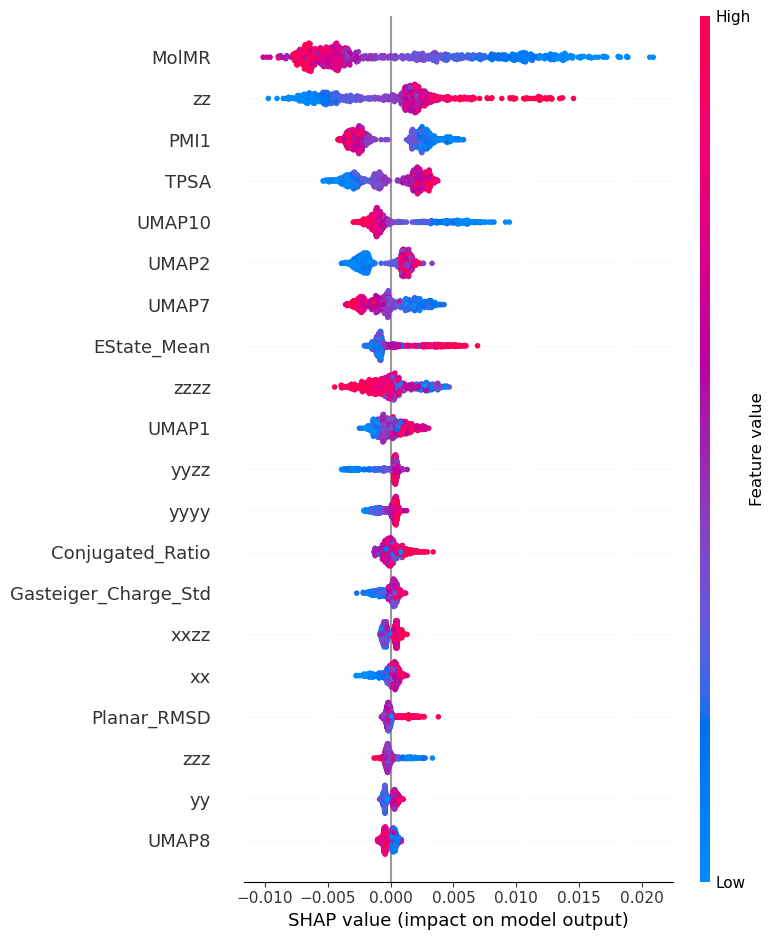

In [59]:
explainer = shap.TreeExplainer(cat_regressor_lc.named_steps['catboostregressor'])
shap_values= explainer.shap_values(x_test_lc)
shap.summary_plot(shap_values, x_test_lc, feature_names=feature_names)